# Nonlinear Source Separation (NSS)

This notebook implements a Deep Image Prior (DIP) model to solve a nonlinear formulation of R2*-based susceptibility source separation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import logging, time
from utils import *
from unet import UNet3D

! python --version

Python 3.9.13


In [2]:
if torch.cuda.is_available(): print(f"GPUs available: {torch.cuda.device_count()}")
gpu = torch.device("cuda")

GPUs available: 1


### Hyperparameters

In [3]:
num_epochs = 1500
lr = 1e-4

r_scaling_factor = 1e-3
lambda_grad = 1e-3
lambda_csf = 1e-1

unet_level_channels = [16, 32, 64]
unet_bottleneck_channel = 128

batch_norm = False

### Data preprocessing

In [4]:
DATA_DIR = f'data_HEMO/1/'  # Path to load data from

DISP_SLICE_Z = 38  # Slice index to display

In [5]:
# Read single mat file from data_dir, containing data from one subject
mat_file, data = read_single_mat_file(DATA_DIR)

print(f"Using data file: {mat_file}")
print(f"Data keys: {data.keys()}")

Using data file: data_HEMO/1/HEMO_1_smv.mat
Data keys: dict_keys(['__header__', '__version__', '__globals__', 'Am', 'Ap', 'B0_dir', 'CF', 'D', 'D_orig', 'Mask', 'Mask_CSF', 'N_std', 'QSM', 'R2p', 'R2s', 'RDF', 'SS', 'SphereK', 'TE', 'alpha', 'beta', 'bf', 'br', 'chi_n_init', 'chi_p_init', 'delta_TE', 'iField', 'iFreq', 'iFreq_raw', 'iMag', 'matrix_size', 'mf', 'mr', 'voxel_size', 'wGm', 'wGr'])


QSM shape: (512, 512, 64)


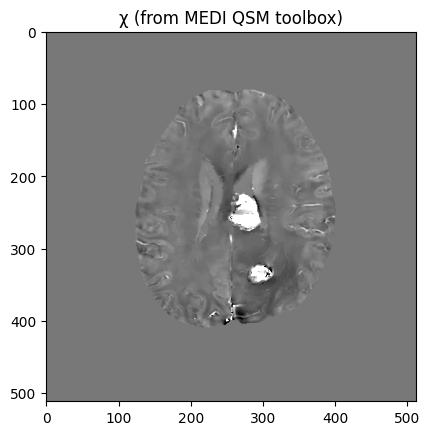

In [6]:
qsm = data['QSM']
print(f'QSM shape: {qsm.shape}')

# Display QSM
plt.imshow(np.rot90(qsm[...,DISP_SLICE_Z], -1), cmap='gray', vmin=-0.2, vmax=0.2)
plt.title("χ (from MEDI QSM toolbox)")
plt.show()

# Solutions for χ+ and χ- from MEDI R2*QSM source separation
chi_pos_medi, chi_neg_medi = data['SS'][...,0], data['SS'][...,1]

In [17]:
r, w, D, f, N_std, br, bf, M_mag, M_r, M_CSF, Mask, mag_img = unpack_data_nonlinear(data, gpu)

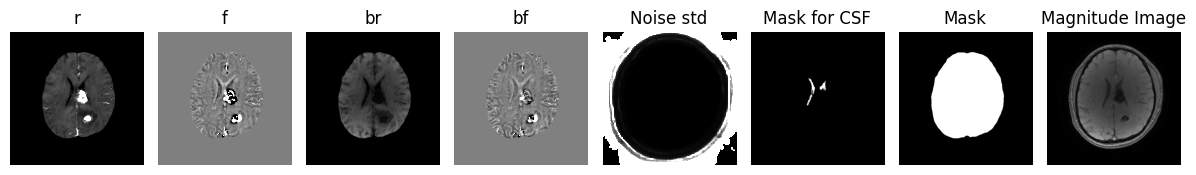

In [34]:
fig, ax = plt.subplots(1, 8, figsize=(12, 6))

ax[0].imshow(np.rot90(r.cpu().squeeze().numpy()[...,DISP_SLICE_Z], -1), cmap='gray', vmin=0, vmax=80)
ax[0].set_title('r')

ax[1].imshow(np.rot90(f.cpu().squeeze().numpy().real[...,DISP_SLICE_Z], -1), cmap='gray', vmin=-.1, vmax=.1)
ax[1].set_title('f')

ax[2].imshow(np.rot90(br.cpu().squeeze().numpy()[...,DISP_SLICE_Z], -1), cmap='gray', vmin=0, vmax=80)
ax[2].set_title('br')

ax[3].imshow(np.rot90(bf.cpu().squeeze().numpy().imag[...,DISP_SLICE_Z], -1), cmap='gray', vmin=-.1, vmax=.1)
ax[3].set_title('bf')

ax[4].imshow(np.rot90(N_std.cpu().squeeze().numpy()[...,DISP_SLICE_Z], -1), cmap='gray', vmin=0, vmax=0.1)
ax[4].set_title('Noise std')

ax[5].imshow(np.rot90(M_CSF.cpu().squeeze().numpy()[...,DISP_SLICE_Z], -1), cmap='gray')
ax[5].set_title('Mask for CSF')

ax[6].imshow(np.rot90(Mask.cpu().squeeze().numpy()[...,DISP_SLICE_Z], -1), cmap='gray')
ax[6].set_title('Mask')

ax[7].imshow(np.rot90(mag_img.cpu().squeeze().numpy()[...,DISP_SLICE_Z], -1), cmap='gray')
ax[7].set_title('Magnitude Image')

for a in ax:
    a.axis('off')
plt.tight_layout()

In [9]:
delta_TE, CF = data['delta_TE'].item(), data['CF'].item()
print(f"delta_TE: {delta_TE}, CF: {CF}")

voxel_size = data['voxel_size'].flatten()
print(f"Voxel size: {voxel_size}")

ppm_to_chi_units_const = 2 * np.pi * delta_TE * CF / 1e6
chi_units_to_ppm_const = 1e6 / (2 * np.pi * delta_TE * CF)

Ap = chi_units_to_ppm_const * 1.21/3*CF/1e6*2*np.pi
Am = chi_units_to_ppm_const * 1.00/3*CF/1e6*2*np.pi

delta_TE: 0.004956000484526157, CF: 127751976
Voxel size: [0.4688 0.4688 2.    ]


In [10]:
inputs_list = [r, f, br, bf]
normalized_inputs = [flatten_complex(normalize_zero_mean_unit_variance(inp)) for inp in inputs_list]

inputs = torch.cat(normalized_inputs, dim=1).type(torch.float32).to(gpu)

x_medi = np.stack((chi_pos_medi, chi_neg_medi), axis=0)
x_medi = torch.tensor(x_medi, dtype=torch.float32).unsqueeze(0).to(gpu)

# Pad inputs to be divisible by 2^3 in each spatial dimension
xyz_shape = inputs.shape[-3:]
print(f"Original data xyz_shape: {xyz_shape}")

inputs = pad_xyz(xyz_shape, inputs)
print(f"Input shape after padding: {inputs.shape}")

Original data xyz_shape: torch.Size([512, 512, 64])
Input shape after padding: torch.Size([1, 4, 512, 512, 64])


### Nonlinear signal model

$$e^{-R_2^* \;+\; if} = e^{-(A_p|\chi^+| + A_m|\chi^-|) \;+\; i\cdot d * (\chi^+ + \chi^-) }$$

In [11]:
class NonlinearSourceSeparation(nn.Module):
    def __init__(self, unet, dipole_kernel, Am, Ap, Mask, r_scaling_factor=1e-3):
        super(NonlinearSourceSeparation, self).__init__()
        self.Am, self.Ap = Am, Ap
        self.Mask = Mask
        self.dipole_kernel = dipole_kernel
        self.unet = unet
        self.r_scaling_factor = r_scaling_factor
        self.out_shape = (self.dipole_kernel.shape[-3], self.dipole_kernel.shape[-2], self.dipole_kernel.shape[-1])

    def forward(self, x):
        output = self.unet(x)

        # Unpad, i.e. crop output to match the original D shape
        output = output[..., :self.out_shape[-3], :self.out_shape[-2], :self.out_shape[-1]]
        
        # Split output into chi_pos and chi_neg
        chi_pos_abs, chi_neg_abs = output[:, 0:1, ...].abs(), output[:, 1:, ...].abs()
        chi = chi_pos_abs - chi_neg_abs

        # Compute predicted f and r from chi
        f = self.get_predicted_f(chi)
        r, _, _ = self.get_predicted_r(chi_pos_abs, chi_neg_abs)

        return chi_pos_abs, chi_neg_abs, chi, f, r

    def get_predicted_f(self, chi):
        chi_ft = torch.fft.fftn(chi, dim=(-1, -2, -3))
        dipole_ft = self.dipole_kernel * chi_ft
        dipole_conv = torch.fft.ifftn(dipole_ft, dim=(-1, -2, -3))
        return dipole_conv
    
    def get_predicted_r(self, chi_pos, chi_neg):
        Achi_pos = self.Ap * chi_pos.abs()
        Achi_neg = self.Am * chi_neg.abs()
        r = Achi_pos + Achi_neg
        return r, Achi_pos, Achi_neg

    def get_predicted_exp(self, chi_pos, chi_neg):
        dipole_conv = self.get_predicted_f(chi_pos - chi_neg)
        pred_r = self.get_predicted_r(chi_pos, chi_neg)[0]
        return torch.exp(1j * dipole_conv) * torch.exp(-1 * pred_r * self.r_scaling_factor)

### Initialize model

In [12]:
# Initialize model and move to GPU
unet = UNet3D(
    in_channels=len(inputs_list), num_classes=2,
    level_channels=unet_level_channels, 
    bottleneck_channel=unet_bottleneck_channel, 
    batch_norm=batch_norm
).to(gpu)

model = NonlinearSourceSeparation(unet, D, Am, Ap, Mask, r_scaling_factor).to(gpu)

# Set up optimizer
optimizer = optim.Adam(model.parameters(), lr=lr)
print_interval = max(num_epochs//10, 1)

### Optimize DIP parameters

In [13]:
start_time = time.time()
interval_duration = 0

for epoch in range(1, num_epochs+1):
    epoch_start_time = time.time()
    
    # Forward pass
    chi_pos, chi_neg, combined_chi, f_pred, r_pred = model(inputs)
    
    # Calculate ||e^(-r + i*f) - e^(-(r^+|chi^+| + r^-|chi^-|) + F^-1 D F(chi^+ + chi^-))||_2^2
    exp_r_f = torch.exp(1j * f) * torch.exp(-1 * r * r_scaling_factor) # scale r to avoid overflow
    exp_chi = model.get_predicted_exp(chi_pos, chi_neg)
    residual_exp = (exp_r_f - exp_chi)
    loss_exp = torch.norm(w * residual_exp, p=2) ** 2

    # MERIT algorithm for reweighting bad voxels
    if epoch <= 10:
        with torch.no_grad():
            reweight_map = get_reweight_map(residual_exp)
            N_std = N_std * reweight_map.square()
            w = get_dataterm_mask(N_std, Mask)

    # Regularization terms for gradient images
    grad_combined = torch.cat(torch.gradient(combined_chi, dim=(-1,-2,-3)), dim=1).abs()
    grad_chi_pos = torch.cat(torch.gradient(chi_pos, dim=(-1,-2,-3)), dim=1).abs()
    grad_chi_neg = torch.cat(torch.gradient(chi_neg, dim=(-1,-2,-3)), dim=1).abs()
    
    loss_grad_combined = lambda_grad * torch.norm(M_mag * grad_combined, p=1)
    loss_grad_chi_pos = lambda_grad * torch.norm(M_r * grad_chi_pos, p=1)
    loss_grad_chi_neg = lambda_grad * torch.norm(M_r * grad_chi_neg, p=1)

    # Regularization terms for CSF
    csf_diff_plus = M_CSF * (chi_pos - combined_chi[M_CSF.bool()].mean())
    csf_diff_minus = M_CSF * (chi_neg - combined_chi[M_CSF.bool()].mean())
    loss_csf_plus = lambda_csf * torch.norm(csf_diff_plus, p=2) ** 2
    loss_csf_minus = lambda_csf * torch.norm(csf_diff_minus, p=2) ** 2

    # Combine all losses
    grad_reg_term = loss_grad_chi_pos + loss_grad_chi_neg + loss_grad_combined 
    csf_reg_term =  loss_csf_plus + loss_csf_minus

    loss = loss_exp
    loss = loss + grad_reg_term 
    loss = loss + csf_reg_term
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()

    # Clip gradients to prevent exploding gradients
    torch.nn.utils.clip_grad_value_(model.parameters(), clip_value=10000.0)

    optimizer.step()
    
    epoch_end_time = time.time()
    interval_duration += epoch_end_time - epoch_start_time

    # Print loss and track outputs at regular intervals
    if (epoch % print_interval == 0) or (epoch == 1):
        avg_epoch_time = interval_duration / (epoch + 1)
        interval_duration = 0  # reset interval duration for next interval
        print(f"Epoch [{epoch:>4}/{num_epochs}]    Loss: {loss.item():.4f}    Time: {avg_epoch_time:.2f} sec/ep")

duration = time.time() - start_time
print(f"Total fitting time: {duration:.2f} seconds ({duration/60:.2f} minutes)")

Epoch [   1/1500]    Loss: 4897.1958    Time: 0.31 sec/ep
Epoch [ 150/1500]    Loss: 1092.9971    Time: 0.40 sec/ep
Epoch [ 300/1500]    Loss: 943.3982    Time: 0.20 sec/ep
Epoch [ 450/1500]    Loss: 885.3238    Time: 0.14 sec/ep
Epoch [ 600/1500]    Loss: 846.2444    Time: 0.10 sec/ep
Epoch [ 750/1500]    Loss: 825.8006    Time: 0.08 sec/ep
Epoch [ 900/1500]    Loss: 801.7331    Time: 0.07 sec/ep
Epoch [1050/1500]    Loss: 788.5351    Time: 0.06 sec/ep
Epoch [1200/1500]    Loss: 776.7491    Time: 0.05 sec/ep
Epoch [1350/1500]    Loss: 767.0167    Time: 0.05 sec/ep
Epoch [1500/1500]    Loss: 759.8289    Time: 0.04 sec/ep
Total fitting time: 614.39 seconds (10.24 minutes)


### Postprocessing outputs

In [14]:
# Post-processing
with torch.no_grad():
    chi_pos, chi_neg, combined_chi, f_pred, r_pred = model(inputs)
    
    chi_pos = chi_pos * chi_units_to_ppm_const * Mask
    chi_neg = chi_neg * chi_units_to_ppm_const * Mask
    combined_chi = combined_chi * chi_units_to_ppm_const * Mask
    
# Convert output to numpy for further processing
output_pos_np = gpu_to_np(chi_pos).squeeze()
output_neg_np = gpu_to_np(chi_neg).squeeze()

print(f"Output χ+ shape: {output_pos_np.shape}, Output χ- shape: {output_neg_np.shape}")

Output χ+ shape: (512, 512, 64), Output χ- shape: (512, 512, 64)


### Comparison of R2*QSM and NSS outputs

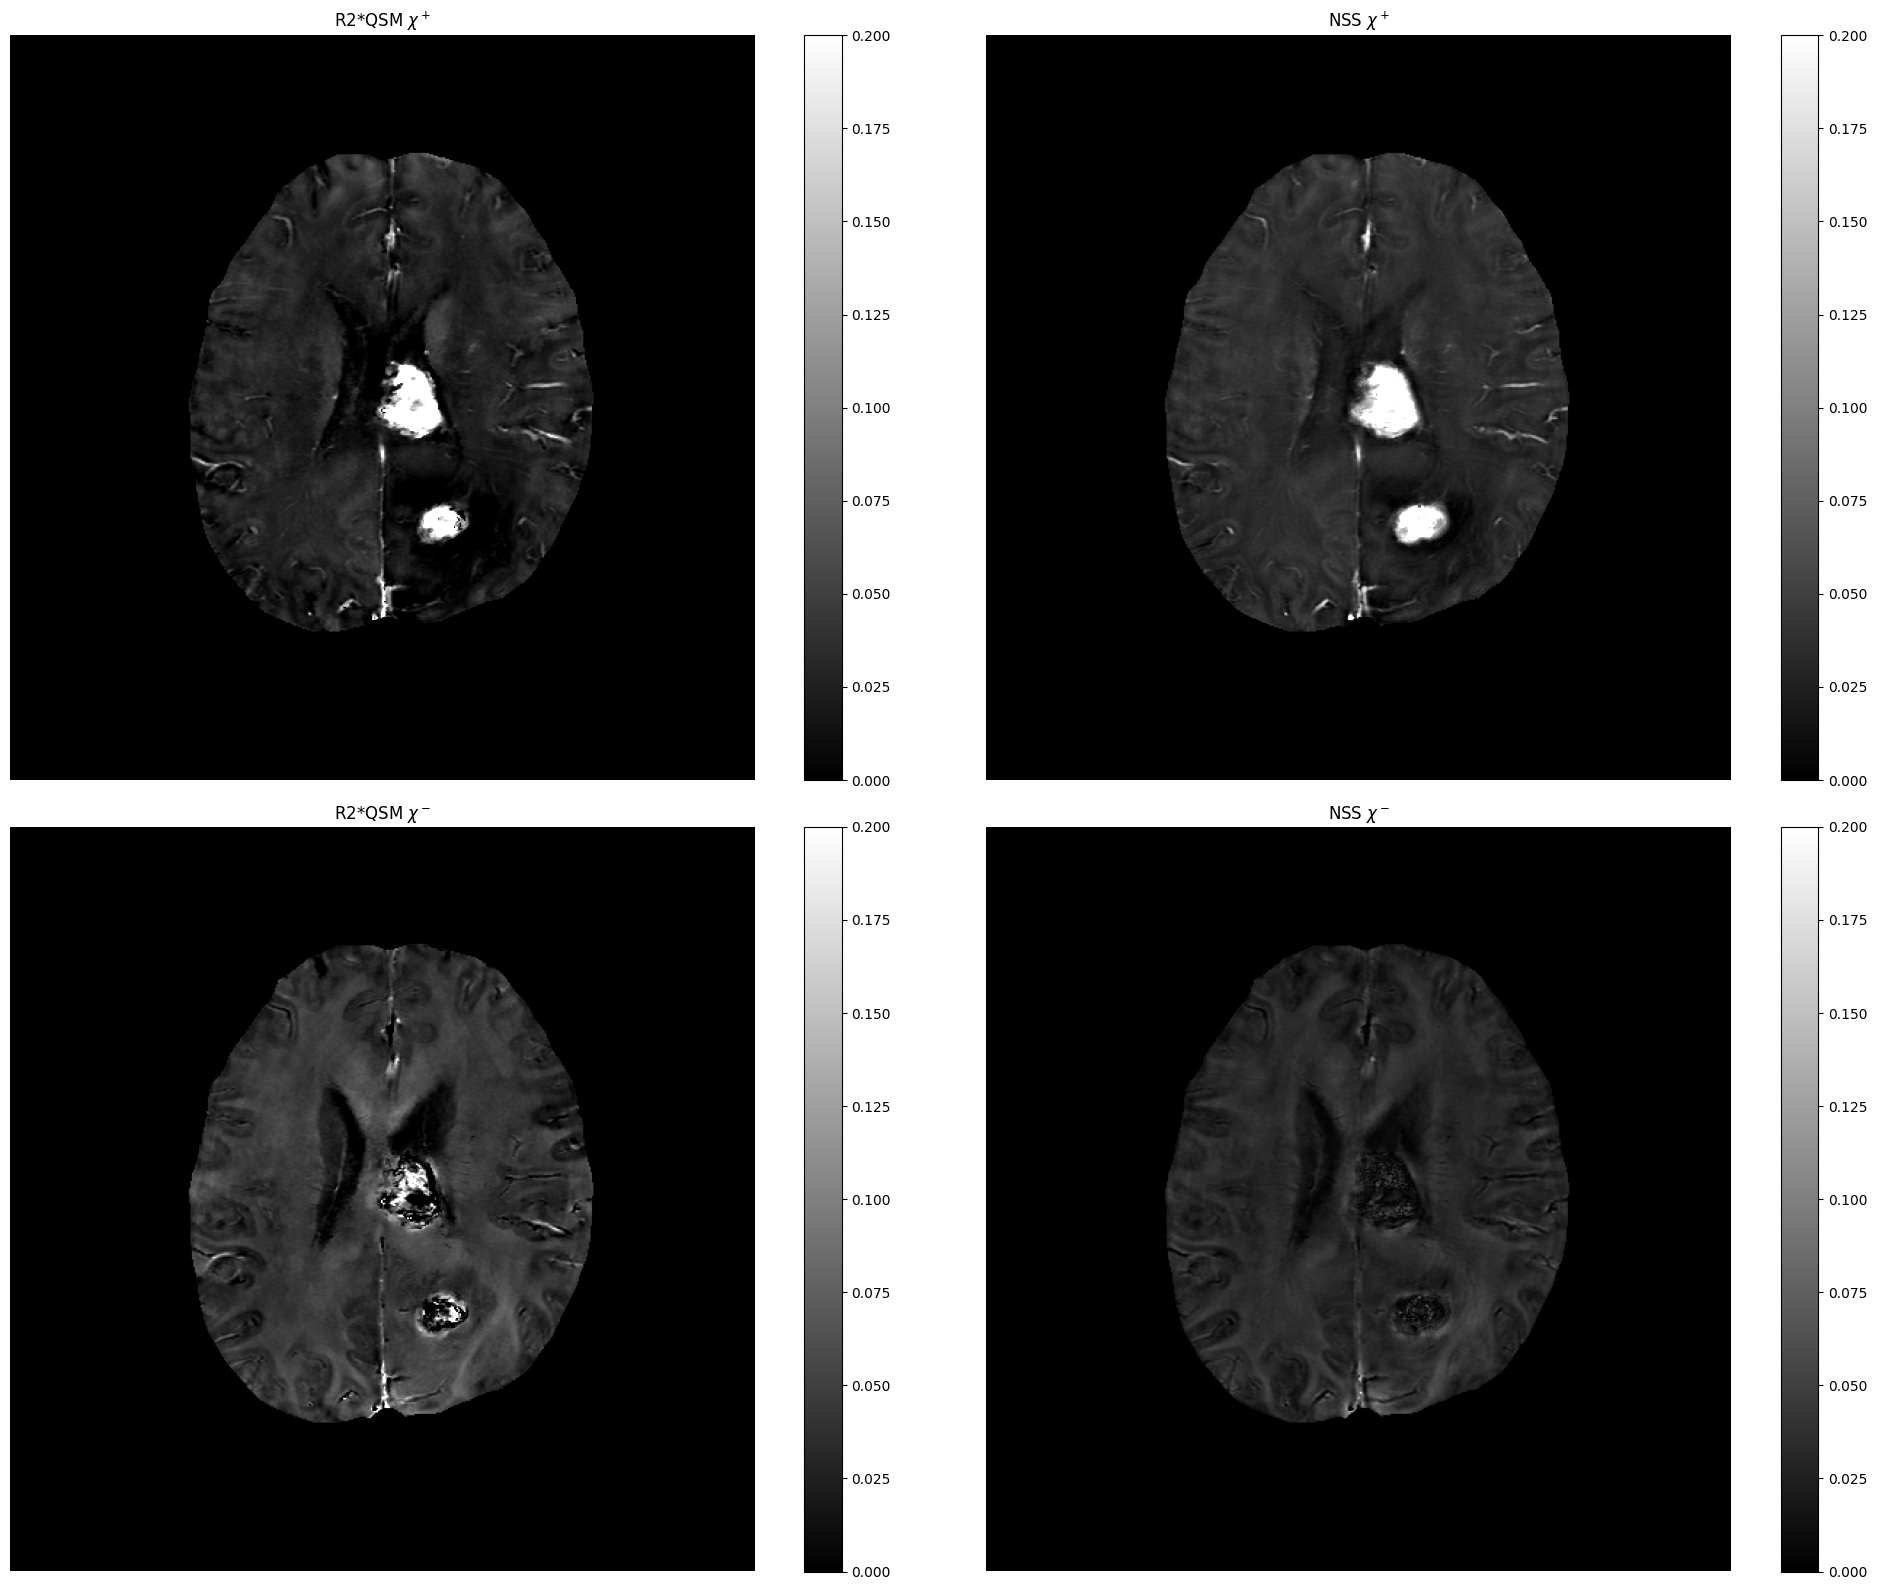

In [15]:
abs_img = lambda x: np.rot90(np.abs(x[...,DISP_SLICE_Z]), -1)

fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes[0, 0].set_title("R2*QSM $χ^+$")
axes[0, 0].axis('off')
im00 = axes[0, 0].imshow(abs_img(chi_pos_medi), cmap='gray', vmax=0.2)
fig.colorbar(im00, ax=axes[0,0])

axes[0, 1].set_title("NSS $χ^+$")
axes[0, 1].axis('off')
im01 = axes[0, 1].imshow(abs_img(output_pos_np), cmap='gray', vmax=0.2)
fig.colorbar(im01, ax=axes[0, 1])

axes[1, 0].set_title("R2*QSM $χ^-$")
axes[1, 0].axis('off')
im10 = axes[1, 0].imshow(abs_img(chi_neg_medi), cmap='gray', vmax=0.2)
fig.colorbar(im10, ax=axes[1, 0])

axes[1, 1].set_title("NSS $χ^-$")
axes[1, 1].axis('off')
im11 = axes[1, 1].imshow(abs_img(output_neg_np), cmap='gray', vmax=0.2)
fig.colorbar(im11, ax=axes[1,1])

plt.tight_layout()